# Q2: Unsupervised Learning - Customer Segmentation

In this notebook I'll segment customers using K-Means and visualise the segments with PCA.

The dataset has columns: `age`, `annual_spend`, `visits_per_month`, `basket_size`, `days_since_last_visit`, and `num_categories_purchased`.

## 1. Data prep

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('../data/q2_customers.csv')
print('Shape:', df.shape)
print()
print('Summary statistics:')
print(df.describe().round(2))
print()
print('Missing values:', df.isnull().sum().sum())


Shape: (500, 6)

Summary statistics:
          age  annual_spend  visits_per_month  basket_size  \
count  500.00        500.00            500.00       500.00   
mean    40.45      48856.95              8.41      2682.29   
std     14.43      32856.80              5.32      2274.96   
min     18.00       5038.00              1.00       212.00   
25%     28.00      19213.25              4.00       727.75   
50%     41.00      44257.00              8.00      2051.50   
75%     50.00      75373.00             12.00      4223.75   
max     69.00     119757.00             19.00      7981.00   

       days_since_last_visit  num_categories_purchased  
count                 500.00                    500.00  
mean                   49.47                      4.66  
std                    49.70                      2.44  
min                     0.00                      1.00  
25%                    12.00                      3.00  
50%                    33.00                      4.00  
75%  

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)
print('Scaled feature means (should be ~0):')
print(X_scaled.mean().round(4))
print()
print('Scaled feature std devs (should be ~1):')
print(X_scaled.std().round(4))


Scaled feature means (should be ~0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Scaled feature std devs (should be ~1):
age                         1.001
annual_spend                1.001
visits_per_month            1.001
basket_size                 1.001
days_since_last_visit       1.001
num_categories_purchased    1.001
dtype: float64


**Why scaling matters here:** K-Means picks clusters by Euclidean distance, and Euclidean distance is dominated by whichever feature has the biggest numeric range. In this data, `annual_spend` goes into the tens of thousands while `visits_per_month` only ranges from about 1 to 12. If I leave it as-is, the clustering basically just splits people by spend and ignores everything else. StandardScaler puts everything on mean 0, std 1, so each feature gets equal say in the distance calculation.

## 2. Choosing K with the elbow method

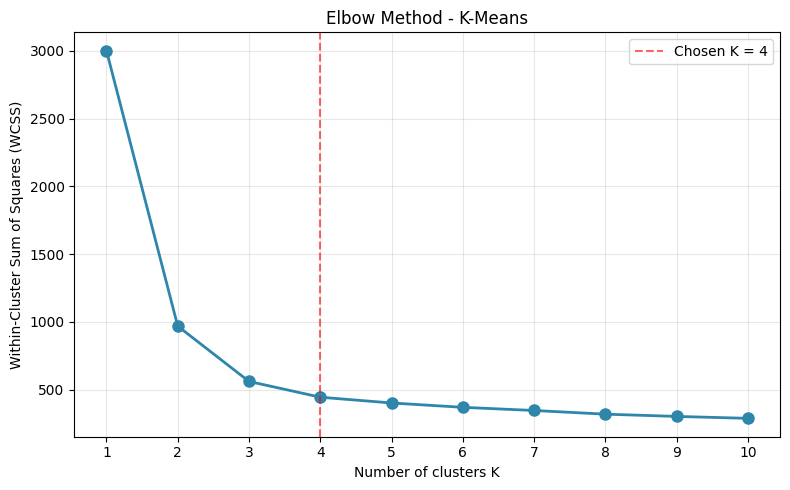

WCSS values:
  K=1: 3000.00
  K=2: 968.99
  K=3: 561.25
  K=4: 444.93
  K=5: 402.37
  K=6: 370.39
  K=7: 346.95
  K=8: 319.90
  K=9: 303.28
  K=10: 289.11


In [3]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), wcss, 'o-', color='#2E86AB', linewidth=2, markersize=8)
ax.set_xlabel('Number of clusters K')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.set_title('Elbow Method - K-Means')
ax.set_xticks(list(K_range))
ax.grid(alpha=0.3)
ax.axvline(4, color='red', linestyle='--', alpha=0.6, label='Chosen K = 4')
ax.legend()
plt.tight_layout()
plt.show()

print('WCSS values:')
for k, w in zip(K_range, wcss):
    print(f'  K={k}: {w:.2f}')


**Why I'm picking K=4:** the WCSS curve drops sharply going from K=1 to K=3, then there's a clear bend (the elbow) around K=4. After that each extra cluster only shaves off a little more WCSS, which means I'm just adding complexity without gaining much explanatory power. K=4 also gives a number of segments the marketing team could actually act on - any more than that and the personas start blurring together. So K=4 it is.

## 3. Running K-Means

In [4]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())


Cluster sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [5]:
# Cluster centroids back on the original (un-scaled) feature scale
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_original,
                           columns=df.columns[:-1],
                           index=[f'Cluster {i}' for i in range(K_FINAL)]).round(2)
print('Cluster centroids (original feature scale):')
print(centroid_df)


Cluster centroids (original feature scale):
             age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.68      14847.37             14.34       558.97   
Cluster 1  57.04      89814.07              2.46      5296.36   
Cluster 2  40.39      43340.73              8.19      2021.68   
Cluster 3  56.52      89036.16              2.59      5750.95   

           days_since_last_visit  num_categories_purchased  
Cluster 0                   9.08                      2.11  
Cluster 1                 148.00                      7.49  
Cluster 2                  35.19                      4.42  
Cluster 3                  65.22                      7.54  


### What each cluster looks like (business personas)

Going through the centroids one at a time:

- **Cluster 0 - Young frequent low-spenders (170 customers).** Average age around 25, lowest annual spend (~15k), highest visits per month (~14), tiny baskets (~560), narrow category footprint (~2 categories), recent last visit (~9 days). Young customers who pop in often but don't buy much each time. The right move for this group is basket-size uplift: bundles, "buy 2 get 1", category cross-sell at checkout, loyalty points that reward bigger baskets rather than visit frequency they already have.

- **Cluster 1 - Lapsed high-value spenders (80 customers).** Older (~57), highest annual spend (~90k), barely visit (~2.5/month), large baskets (~5,300), broad categories (~7.5), and the longest gap since their last visit (~148 days). They buy a lot when they show up but they haven't shown up in a while. Most valuable group to win back since the upside per recovered customer is huge. Targeted reactivation - personal outreach, exclusive previews, win-back offers on categories they've bought before.

- **Cluster 2 - Steady mid-tier mainstream (165 customers).** Middle of the road on everything: age 40, spend 43k, 8 visits/month, basket 2k, 4-ish categories, last visit 35 days ago. The bread-and-butter base. Retention-focused communications and gentle upsell work well here. Deep win-back discounts would be wasted on them since they aren't lapsing.

- **Cluster 3 - Active high-value loyalists (85 customers).** Profile is similar to Cluster 1 (older, high spend, big basket, broad categories) but they actually still visit - last visit ~65 days vs 148 for Cluster 1. These are the genuine VIPs. Worth investing in retention here since the revenue per customer is the highest in the base.

## 4. PCA

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio per component:')
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f'  PC{i}: {ratio:.4f} ({ratio*100:.2f}%)')
print(f'Cumulative variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%')


Explained variance ratio per component:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
Cumulative variance explained by 2 PCs: 89.13%


In [7]:
# Feature loadings (components_): rows = PCs, cols = original features
loadings = pd.DataFrame(pca.components_,
                        columns=df.columns[:-1],
                        index=['PC1', 'PC2']).round(4)
print('Feature loadings (PC1 and PC2):')
print(loadings.T)  # transpose so rows = features, easier to read


Feature loadings (PC1 and PC2):
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


**Reading PC1 and PC2 from the loadings:**

- **PC1 (84% of variance) is basically a "spend vs frequency" axis.** It loads positively on `annual_spend` (0.42), `basket_size` (0.41), `num_categories_purchased` (0.41), and `age` (0.41), and negatively on `visits_per_month` (-0.41). So high PC1 = older customer who buys a lot per trip across many categories but doesn't visit often. Low PC1 = younger customer who comes in often but doesn't buy much each time. This single axis already does most of the work in separating the clusters - it's capturing 84% of the variance.

- **PC2 (5.6% of variance) is essentially a recency axis.** It's pretty much all about `days_since_last_visit` (loading 0.91), with everything else contributing very little. PC2 separates customers by recency, holding their PC1 profile constant. This is what lets it pull apart Cluster 1 (lapsed high-spenders, high PC2) from Cluster 3 (active high-spenders, lower PC2) even though they look similar on PC1.

Between them, PC1 and PC2 capture about 89% of the variance and give us the two business levers - "spend depth vs visit frequency" and "recency" - that describe the segmentation.

## 5. Visualising the clusters

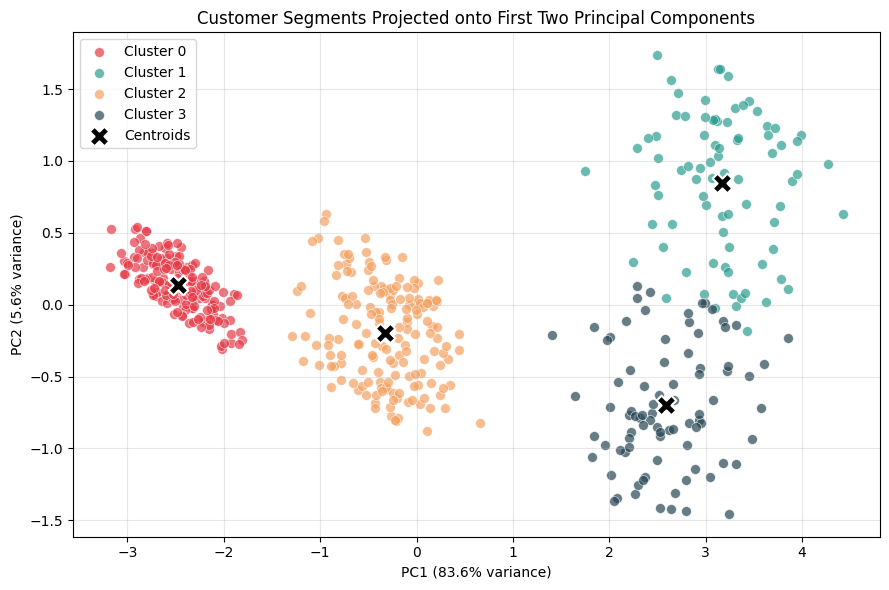

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E63946', '#2A9D8F', '#F4A261', '#264653']
for k in range(K_FINAL):
    mask = cluster_labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[k], label=f'Cluster {k}',
               alpha=0.7, s=50, edgecolor='white', linewidth=0.5)

# Project centroids into PCA space
centroids_pca = pca.transform(centroids_scaled)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', c='black', s=200, label='Centroids', edgecolor='white', linewidth=1.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Customer Segments Projected onto First Two Principal Components')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
